# Matrix Factorization Methods

For this project I'll reuse the recommender system created in [project_2](https://github.com/Siganz/CUNY_Assignments/blob/main/612/Project_2/project_2.ipynb), which uses Yelp's open data that was filtered down to Philadelphia restaurants with a random sample of 500 reviewers selected.

## Sources

I used the Surprise Python package for the item-item KNN and SVD models. The Yelp restaurant data comes from the Yelp Open Dataset, and I reused the cleaned Philadelphia restaurant sample from my previous recommender project. For this project, I reused my content-based recommender and added SVD as the new matrix factorization model.

The original dataset is around 4 GB from [Yelp](https://business.yelp.com/data/resources/open-dataset/), the data cleaning was done locally in the previous project submission. 

## Base Metrics

In the previous assignment I forgot to include some overall metrics, so I'd like to add them to this new project.

In [223]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load data
users_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_users_sample.parquet"
business_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_businesses_sample.parquet"
reviews_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_reviews_sample.parquet"

df_users = pd.read_parquet(users_url)
df_businesses = pd.read_parquet(business_url)
df_reviews = pd.read_parquet(reviews_url)

In [224]:
# Overall Data Summary

n_users = df_reviews["user_id"].nunique()
n_businesses = df_reviews["business_id"].nunique()
n_reviews = len(df_reviews)

possible_ratings = n_users * n_businesses
density = n_reviews / possible_ratings
sparsity = 1 - density

summary_df = pd.DataFrame({
    "Metric": [
        "Unique users",
        "Unique businesses",
        "Total reviews",
        "Possible user-business ratings",
        "Rating density (%)",
        "Rating sparsity (%)"
    ],
    "Value": [
        n_users,
        n_businesses,
        n_reviews,
        possible_ratings,
        density * 100,
        sparsity * 100
    ]
})

summary_df["Value"] = summary_df["Value"].round(2)

display(summary_df)

,Metric,Value
0,Unique users,500.0
1,Unique businesses,3653.0
2,Total reviews,20028.0
3,Possible user-business ratings,1826500.0
4,Rating density (%),1.1
5,Rating sparsity (%),98.9


The ratings matrix is pretty sparse. Out of 1,826,500 possible user-business rating combinations, only 20,028 ratings are observed. This means the matrix has a rating density of about 1.10% and a sparsity of about 98.90%. However, this is pretty common for recommender matrices since most users only rate a small number of businesses.

,stars,review_count
0,1,856
1,2,1509
2,3,3831
3,4,7465
4,5,6367


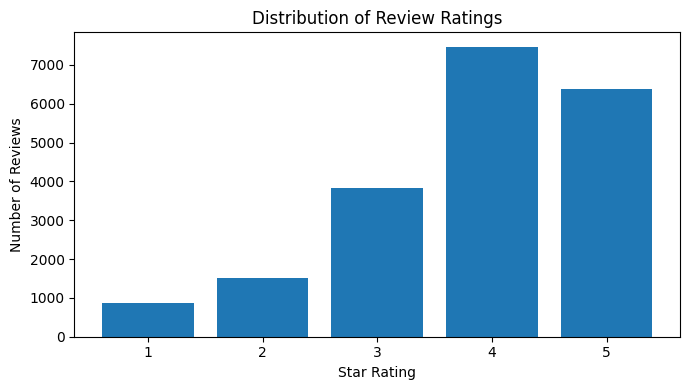

In [225]:
# Rating Distribution

rating_counts = df_reviews["stars"].value_counts().sort_index()

display(rating_counts.rename("review_count").reset_index().rename(columns={"index": "stars"}))

plt.figure(figsize=(7, 4))
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Distribution of Review Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rating_counts.index)
plt.tight_layout()
plt.show()

The review ratings are skewed toward higher scores. Most reviews are either 4 or 5 stars, while low ratings are much less common. This means the dataset is mostly positive, which is useful to know before modeling because the recommenders are learning from a ratings distribution that is not evenly balanced across all star levels.

count    500.000000
mean      40.056000
std       42.781461
min        3.000000
25%       19.000000
50%       26.000000
75%       43.250000
max      403.000000
dtype: float64

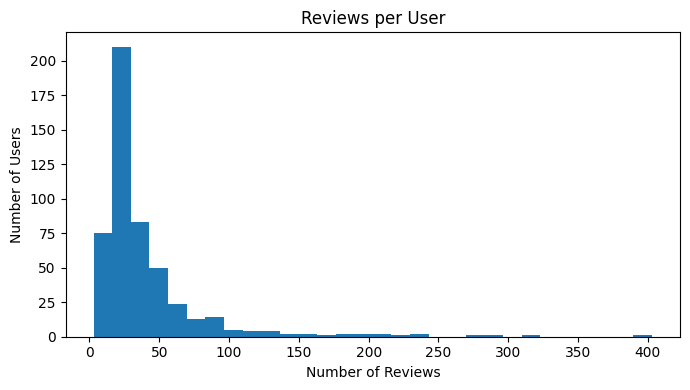

In [226]:
# Reviews per User

reviews_per_user = df_reviews.groupby("user_id").size()

display(reviews_per_user.describe())

plt.figure(figsize=(7, 4))
plt.hist(reviews_per_user, bins=30)
plt.title("Reviews per User")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

Most users in the dataset have around 20 to 40 reviews, but the distribution has a strong right skew because of a smaller number of super reviewers. Some users have 100+ reviews, and one user has close to 400 reviews. That's not bad for the 500 user snippet, since users with more reviews inform the recommender models better. 

count    3653.000000
mean        5.482617
std         8.011837
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       101.000000
dtype: float64

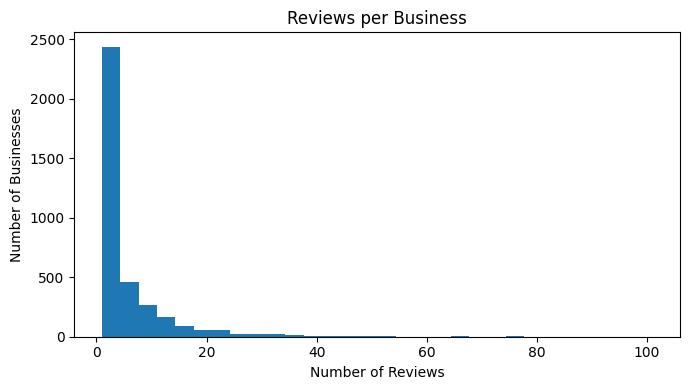

In [227]:
# Reviews per Business

reviews_per_business = df_reviews.groupby("business_id").size()

display(reviews_per_business.describe())

plt.figure(figsize=(7, 4))
plt.hist(reviews_per_business, bins=30)
plt.title("Reviews per Business")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Businesses")
plt.tight_layout()
plt.show()

Reviews per business are kinda low. The average business has around 5 reviews, and the median is only 3, so a lot of businesses have very little review history. The high standard deviation comes from a few outlier businesses with much higher review counts. This helps explain why item-item collaborative filtering can struggle here, since many businesses do not have enough overlapping reviewers.

,name,clean_categories,review_count,average_rating
3586,Reading Terminal Market,"Candy Stores, Shopping, Department Stores, Fas...",101,4.514851
2304,Zahav,"Nightlife, Bars, Ethnic Food, Middle Eastern, ...",91,4.560440
594,El Vez,"Lounges, Bars, Nightlife, Breakfast & Brunch, ...",89,3.752809
443,Barbuzzo,"Mediterranean, Pizza, Italian",77,4.168831
1673,Amada,"Spanish, Breakfast & Brunch, Tapas Bars, Iberian",75,4.360000
644,Dim Sum Garden,"Chinese, Dim Sum, Asian Fusion, Shanghainese",72,3.819444
2673,Parc,"French, Wine Bars, Nightlife, American (New), ...",70,3.985714
566,The Dandelion,"British, Gastropubs, Bars, Nightlife",66,4.045455
1477,Monk's Cafe,"Nightlife, Pubs, Bars, Belgian, Gastropubs",66,4.090909
911,Village Whiskey,"Bars, Nightlife, Whiskey Bars, Burgers, Americ...",64,4.078125


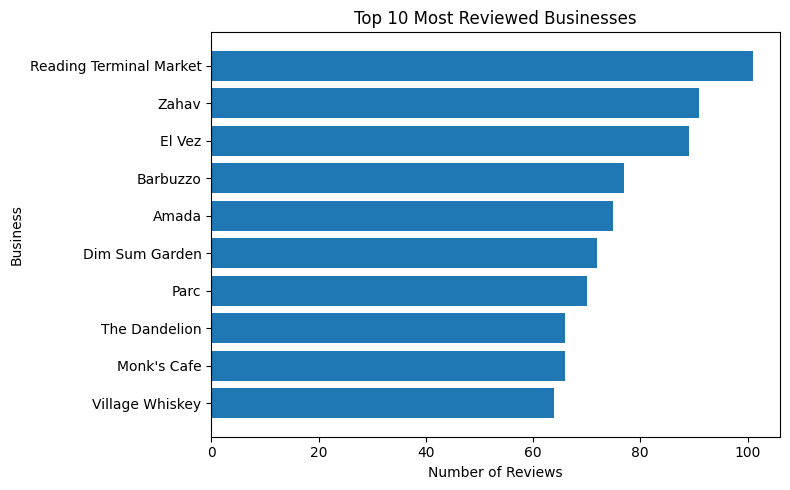

In [228]:
# Most Reviewed Businesses

business_review_summary = (
    df_reviews.groupby("business_id")
    .agg(
        review_count=("stars", "count"),
        average_rating=("stars", "mean")
    )
    .reset_index()
    .merge(
        df_businesses[["business_id", "name", "clean_categories"]],
        on="business_id",
        how="left"
    )
)

top_reviewed = business_review_summary.sort_values(
    "review_count",
    ascending=False
).head(10)

display(top_reviewed[["name", "clean_categories", "review_count", "average_rating"]])

plt.figure(figsize=(8, 5))
plt.barh(top_reviewed["name"][::-1], top_reviewed["review_count"][::-1])
plt.title("Top 10 Most Reviewed Businesses")
plt.xlabel("Number of Reviews")
plt.ylabel("Business")
plt.tight_layout()
plt.show()

The most reviewed businesses have far more review history than the average business in the dataset. While the median business only has around 3 reviews, the top businesses have 60 to 100+ reviews! Most businesses have very limited review history, but these high-review businesses are the places where item-item comparisons and rating patterns have more data to work with.

In [229]:
# Storing previous showcased users to serve as comparisons later on. 
user_id_1="OJorsQjotS1dIv--IVifCA"
user_id_2="ewF8tQ01PgwSJbWEdFKS8A"

## Previous Recommenders

### Content-Based Recommender

This section reuses the content-based recommender from my previous Project 2 submission.

The model builds user profiles from business categories. First, each business is represented as a TF-IDF vector based on its cleaned category labels. Then, for each user, the model identifies businesses they rated 4 stars or higher and averages those business vectors into a single user profile. Recommendations are generated by comparing the user profile to all candidate businesses using cosine similarity, while excluding businesses the user has already reviewed. The final output is a tidy DataFrame containing the top three personalized recommendations for each user.

I decided to use `high_rated = df_reviews[df_reviews["stars"] >= 4]` because 4+ star reviews provide the clearest positive preference signal. Since the content-based model builds user profiles from businesses a user liked, using lower-rated reviews would risk mixing disliked businesses into the profile.

I added a check (that wasn't in the original) to review the coverage:

- 69.06% of all reviews are 4 stars or higher.
- 100% of users have at least one 4+ star review.
- 83% of businesses have at least one 4+ star review.

This shows that the 4+ threshold keeps most of the review data while still focusing the recommender on positive user preferences. I should've included it in the previous project. 

In [230]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# Load data
users_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_users_sample.parquet"
business_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_businesses_sample.parquet"
reviews_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_reviews_sample.parquet"

df_users = pd.read_parquet(users_url)
df_businesses = pd.read_parquet(business_url)
df_reviews = pd.read_parquet(reviews_url)

# Reset index so cosine scores align with business rows
df_businesses = df_businesses.reset_index(drop=True)

# Create item features from cleaned business categories
vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(", "),
    token_pattern=None
)

item_features = vectorizer.fit_transform(
    df_businesses["clean_categories"].fillna("")
)

# Build user profiles from businesses rated 4+
high_rated = df_reviews[df_reviews["stars"] >= 4]

user_profiles = {}

for user_id in df_users["user_id"]:
    user_business_ids = high_rated.loc[
        high_rated["user_id"] == user_id,
        "business_id"
    ]

    indices = df_businesses[
        df_businesses["business_id"].isin(user_business_ids)
    ].index

    if len(indices) > 0:
        user_profiles[user_id] = np.asarray(
            item_features[indices].mean(axis=0)
        ).ravel()


def get_content_based_recommendations(user_id, top_n=3):
    """
    Recommend businesses based on category similarity to businesses
    the user previously rated 4 stars or higher.
    """
    if user_id not in user_profiles:
        return "No high-rated businesses found"

    user_vec = user_profiles[user_id]

    sims = cosine_similarity(
        user_vec.reshape(1, -1),
        item_features
    ).flatten()

    reviewed = set(
        df_reviews.loc[
            df_reviews["user_id"] == user_id,
            "business_id"
        ]
    )

    candidates = df_businesses[
        ~df_businesses["business_id"].isin(reviewed)
    ].copy()

    candidates["score"] = sims[candidates.index]

    return candidates.nlargest(top_n, "score")[
        ["name", "clean_categories", "score"]
    ]


def build_content_based_recommendations_df(df_users, recommend_func, top_n=3):
    """
    Build a recommendation table for all users.
    """
    recommendation_rows = []

    for user_id in df_users["user_id"]:
        recs = recommend_func(user_id, top_n=top_n)

        # Skip users with no recommendations
        if isinstance(recs, str):
            continue

        user_name = df_users.loc[
            df_users["user_id"] == user_id,
            "name"
        ].iloc[0]

        row = {
            "user_id": user_id,
            "name": user_name,
        }

        for i in range(top_n):
            if len(recs) > i:
                row[f"rec_{i+1}_name"] = recs["name"].iloc[i]
                row[f"rec_{i+1}_categories"] = recs["clean_categories"].iloc[i]
                row[f"rec_{i+1}_score"] = recs["score"].iloc[i]
            else:
                row[f"rec_{i+1}_name"] = None
                row[f"rec_{i+1}_categories"] = None
                row[f"rec_{i+1}_score"] = None

        recommendation_rows.append(row)

    return pd.DataFrame(recommendation_rows)

In [231]:
# Reviews with 4+ stars
total_reviews = len(df_reviews)
high_reviews = (df_reviews["stars"] >= 4).sum()

print("=== Review Coverage ===")
print(f"Total reviews:        {total_reviews:,}")
print(f"4+ star reviews:      {high_reviews:,}")
print(f"Percent 4+ reviews:   {high_reviews / total_reviews:.2%}")

=== Review Coverage ===
Total reviews:        20,028
4+ star reviews:      13,832
Percent 4+ reviews:   69.06%


In [232]:
# Users with at least one 4+ review
users_with_high_reviews = df_reviews.loc[
    df_reviews["stars"] >= 4,
    "user_id"
].nunique()

total_users = df_users["user_id"].nunique()

print("\n=== User Coverage ===")
print(f"Total users:               {total_users:,}")
print(f"Users with 1+ 4-star review: {users_with_high_reviews:,}")
print(f"Percent users covered:     {users_with_high_reviews / total_users:.2%}")


=== User Coverage ===
Total users:               500
Users with 1+ 4-star review: 500
Percent users covered:     100.00%


In [233]:
high_rated_businesses = df_reviews.loc[
    df_reviews["stars"] >= 4,
    "business_id"
].nunique()

total_businesses = df_businesses["business_id"].nunique()

print("=== Business Coverage ===")
print(f"Total businesses:                 {total_businesses:,}")
print(f"Businesses with 1+ 4-star review: {high_rated_businesses:,}")
print(f"Percent businesses covered:       {high_rated_businesses / total_businesses:.2%}")

=== Business Coverage ===
Total businesses:                 3,653
Businesses with 1+ 4-star review: 3,015
Percent businesses covered:       82.53%


In [234]:
df_content_based_recommendations = build_content_based_recommendations_df(
    df_users,
    get_content_based_recommendations,
    top_n=3
)

df_content_based_recommendations.head()

,user_id,name,rec_1_name,rec_1_categories,rec_1_score,rec_2_name,rec_2_categories,rec_2_score,rec_3_name,rec_3_categories,rec_3_score
0,OJorsQjotS1dIv--IVifCA,Cindy,Bumblefish Sushi & More,"Sushi Bars, Specialty Food, Asian Fusion, Seaf...",0.612330,Dream House Asian Bistro,"Sushi Bars, Thai, Asian Fusion, Japanese, Chinese",0.578434,Umai Royal,"Bars, Asian Fusion, Sushi Bars, Chinese, Japan...",0.556895
1,6GHPzEmQNTjC7E3P9VF44w,Rachel,Revolution House,"Pizza, Beer, Wine & Spirits, Nightlife, Americ...",0.713772,The Boilermaker,"Bars, American (New), Nightlife, Beer, Wine & ...",0.655199,In Riva,"Italian, Nightlife, Pizza, Bars, Cocktail Bars...",0.642129
2,Fu8D01UpP5DNnaI7dP9xEw,Ivonne,A La Mousse,"Coffee & Tea, Cafes, Bakeries, Desserts",0.543920,Small Oven Pastry Shop,"Bakeries, Cafes, Desserts",0.533841,Function Coffee Labs,"Bakeries, Breakfast & Brunch, Desserts, Coffee...",0.530361
3,by2k9-QcUwRVIvVOeLU2lg,Sarah,Plenty Cafe,"American (New), Bars, Sandwiches, Nightlife, C...",0.623410,The Gold Standard Cafe,"American (Traditional), American (New), Breakf...",0.597714,Plenty Café,"American (New), Wine Bars, Cafes, Coffee & Tea...",0.585128
4,FoO5vOMb3_nKGmMiDUm8lA,picunte,Revolution House,"Pizza, Beer, Wine & Spirits, Nightlife, Americ...",0.696303,Chestnut 7,"Pizza, American (New), Bars, Burgers, Nightlif...",0.627544,Square 1682,"American (New), Breakfast & Brunch, Bars, Nigh...",0.623902


### Item-Item Similarity 

I revamped the item-item collaborative-filtering model using Surprise so it could be evaluated consistently with the SVD model. Since both models predict explicit star ratings, I compared them using cross-validated RMSE and MAE. RMSE measures the typical prediction error while penalizing larger mistakes more heavily, and MAE measures the average absolute difference between the predicted and actual rating. Lower values indicate better rating-prediction performance.

I also included a `for` loop within the evaluation to test different `min_support` values. In the item-item model, `min_support` is the minimum number of overlapping users required between two businesses before Surprise computes their similarity. I tested `[1, 2, 3, 5, 10]` because `min_support=1` already produced low RMSE and MAE scores, and I wanted to see whether requiring more shared reviewers would reduce prediction error.

In [235]:
import pandas as pd
import numpy as np
from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import cross_validate, KFold

# Load data
users_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_users_sample.parquet"
business_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_businesses_sample.parquet"
reviews_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_reviews_sample.parquet"

df_users = pd.read_parquet(users_url).copy()
df_businesses = pd.read_parquet(business_url).copy()
df_reviews = pd.read_parquet(reviews_url).copy()

# Prepare data for Surprise
ratings = df_reviews[["user_id", "business_id", "stars"]].copy()
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings, reader)


def evaluate_item_item_knn(data, min_support_values, cv=5):
    """
    Evaluate item-item KNN collaborative filtering model across different min_support values.
    """
    results = []

    # Create reproducible cross-validation splits
    kfold = KFold(n_splits=cv, random_state=42, shuffle=True)

    # Test each min_support value
    for min_support in min_support_values:
        sim_options = {
            "name": "cosine",
            "user_based": False,      # False = item-item collaborative filtering
            "min_support": min_support
        }

        # Build KNN model with current similarity settings
        algo = KNNBasic(sim_options=sim_options, verbose=False)

        print(f"\n=== Testing min_support = {min_support} ===")

        # Evaluate model with RMSE and MAE
        cv_results = cross_validate(
            algo,
            data,
            measures=["RMSE", "MAE"],
            cv=kfold,
            verbose=True
        )

        # Store average performance across folds
        results.append({
            "min_support": min_support,
            "RMSE_mean": np.mean(cv_results["test_rmse"]),
            "RMSE_std": np.std(cv_results["test_rmse"]),
            "MAE_mean": np.mean(cv_results["test_mae"]),
            "MAE_std": np.std(cv_results["test_mae"]),
            "fit_time_mean": np.mean(cv_results["fit_time"]),
            "test_time_mean": np.mean(cv_results["test_time"])
        })

    # Return results sorted by lowest RMSE
    return pd.DataFrame(results).sort_values("RMSE_mean")


# Run evaluation across different min_support values
min_support_values = [1, 2, 3, 5, 10]

results_df = evaluate_item_item_knn(
    data=data,
    min_support_values=min_support_values,
    cv=5
)

display(results_df)


=== Testing min_support = 1 ===
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.0985  1.0763  1.0673  1.1029  1.0810  1.0852  0.0135  
MAE (testset)     0.8501  0.8273  0.8159  0.8423  0.8235  0.8318  0.0126  
Fit time          0.19    0.19    0.19    0.19    0.19    0.19    0.00    
Test time         0.07    0.08    0.08    0.08    0.07    0.08    0.00    

=== Testing min_support = 2 ===
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.1306  1.1234  1.0920  1.1290  1.0970  1.1144  0.0165  
MAE (testset)     0.8617  0.8607  0.8332  0.8568  0.8281  0.8481  0.0144  
Fit time          0.18    0.18    0.18    0.19    0.19    0.18    0.00    
Test time         0.07    0.07    0.07    0.07    0.08    0.07    0.00    

=== Testing min_support = 3 ===
Evaluating RMSE, MAE of algorithm

,min_support,RMSE_mean,RMSE_std,MAE_mean,MAE_std,fit_time_mean,test_time_mean
0,1,1.085200,0.013480,0.831847,0.012556,0.190986,0.075774
4,10,1.100861,0.009000,0.842637,0.003818,0.184891,0.059752
1,2,1.114382,0.016506,0.848093,0.014424,0.184435,0.070498
3,5,1.120171,0.014377,0.855212,0.012761,0.182303,0.064536
2,3,1.124515,0.010671,0.856435,0.011041,0.194117,0.072769


In [236]:
# We select the best result from results_df
best_min_support = int(results_df.iloc[0]["min_support"])

print(f"Best min_support: {best_min_support}")

Best min_support: 1


In [237]:
# We create a dict based off that previous best result
final_sim_options = {
    "name": "cosine",
    "user_based": False,
    "min_support": best_min_support
}

# KNNBasic from surprise 
final_item_item_algo = KNNBasic(
    sim_options=final_sim_options,
    verbose=False
)

# Train the dataset
trainset = data.build_full_trainset()
final_item_item_algo.fit(trainset)

In [ ]:
# Getting the recommendations from the dataset
def get_item_item_recommendations(user_id, top_n=3):
    """
    Recommends new businesses by predicting which unrated places a user would probably score the highest.
    """
    
    # Get businesses this user has already reviewed
    reviewed_businesses = set(
        df_reviews.loc[
            df_reviews["user_id"] == user_id,
            "business_id"
        ]
    )

    # Keep only businesses the user has not reviewed
    candidates = df_businesses[
        ~df_businesses["business_id"].isin(reviewed_businesses)
    ].copy()

    # Predict this user's rating for each candidate business
    candidates["predicted_rating"] = candidates["business_id"].apply(
        lambda business_id: final_item_item_algo.predict(user_id, business_id).est
    )

    # Return the highest predicted ratings
    return candidates.nlargest(top_n, "predicted_rating")[
        ["name", "clean_categories", "predicted_rating"]
    ]


## New Recommender

### Singular Value Decomposition (SVD) Recommender

I used the Surprise package to implement an SVD recommender. SVD is a model-based collaborative filtering method that learns latent user and business factors from the rating data. After learning these hidden patterns, the model predicts how a user might rate businesses they have not reviewed yet.

Surprise makes this easier because I do not have to manually fill in every missing user-business rating. I just give it the ratings that exist, and the SVD model learns from those.

In [ ]:
from surprise import SVD, Dataset, Reader

# Original data
users_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_users_sample.parquet"
business_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_businesses_sample.parquet"
reviews_url = "https://raw.githubusercontent.com/Siganz/CUNY_Assignments/main/612/Project_2/df_reviews_sample.parquet"

# Read parquets
df_users = pd.read_parquet(users_url)
df_businesses = pd.read_parquet(business_url)
df_reviews = pd.read_parquet(reviews_url)

# Recreate the original parameters of the previous model
reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    df_reviews[['user_id', 'business_id', 'stars']], 
    reader
)

trainset = data.build_full_trainset()

print("Surprise dataset created successfully!")
print(
    f"Users: {trainset.n_users}, "
    f"Businesses: {trainset.n_items}, "
    f"Ratings: {trainset.n_ratings}"
)

Surprise dataset created successfully!
Users: 500, Businesses: 3653, Ratings: 20028


In [ ]:
# Create SVD model
svd = SVD(
    n_factors=50,     # number of hidden/latent features (try 20, 50, or 100)
    n_epochs=20,      # how many times the model learns from the data
    lr_all=0.005,     # learning speed
    reg_all=0.02,     # prevents overfitting
    random_state=42
)

# Cross-validation
print("\n=== SVD Cross-Validation Results ===")
cv_results = cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)


=== SVD Cross-Validation Results ===
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9774  1.0157  0.9811  0.9880  1.0065  0.9937  0.0149  
MAE (testset)     0.7650  0.7944  0.7681  0.7736  0.7842  0.7771  0.0109  
Fit time          0.03    0.04    0.04    0.04    0.04    0.04    0.00    
Test time         0.01    0.05    0.01    0.01    0.01    0.02    0.02    


Let's see if we can lower the cross-validation results by sampling different parameters. 

In [241]:
from surprise.model_selection import KFold


def evaluate_svd_params(data, param_grid, cv=5):
    """
    Evaluate SVD models across parameter combinations using RMSE and MAE.
    """
    results = []
    kfold = KFold(n_splits=cv, random_state=42, shuffle=True)

    for params in param_grid:
        algo = SVD(
            n_factors=params["n_factors"],
            n_epochs=params["n_epochs"],
            lr_all=params["lr_all"],
            reg_all=params["reg_all"],
            random_state=42
        )

        print(f"\n=== Testing SVD params: {params} ===")

        cv_results = cross_validate(
            algo,
            data,
            measures=["RMSE", "MAE"],
            cv=kfold,
            verbose=True
        )

        results.append({
            **params,
            "RMSE_mean": np.mean(cv_results["test_rmse"]),
            "RMSE_std": np.std(cv_results["test_rmse"]),
            "MAE_mean": np.mean(cv_results["test_mae"]),
            "MAE_std": np.std(cv_results["test_mae"]),
            "fit_time_mean": np.mean(cv_results["fit_time"]),
            "test_time_mean": np.mean(cv_results["test_time"])
        })

    return pd.DataFrame(results).sort_values("RMSE_mean")

Following Surprise's documentation, I created a `param_grid` to test a few different SVD settings. The goal was to see if any combination could lower the RMSE score. I used RMSE as the main metric because it punishes bigger prediction mistakes more than MAE, but I still included MAE because it is easier to understand as the average rating error.

In [ ]:
# Creating a grid of possible parameter combinations to see which would be best
param_grid = [
    {"n_factors": 20, "n_epochs": 20, "lr_all": 0.005, "reg_all": 0.02},
    {"n_factors": 50, "n_epochs": 20, "lr_all": 0.005, "reg_all": 0.02},
    {"n_factors": 100, "n_epochs": 20, "lr_all": 0.005, "reg_all": 0.02},
    {"n_factors": 20, "n_epochs": 30, "lr_all": 0.005, "reg_all": 0.02},
    {"n_factors": 20, "n_epochs": 40, "lr_all": 0.005, "reg_all": 0.02},
    {"n_factors": 20, "n_epochs": 50, "lr_all": 0.005, "reg_all": 0.02},
]

svd_results_df = evaluate_svd_params(
    data=data,
    param_grid=param_grid,
    cv=5
)

svd_results_df


=== Testing SVD params: {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02} ===
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.0019  0.9915  0.9800  1.0017  0.9953  0.9941  0.0081  
MAE (testset)     0.7868  0.7742  0.7640  0.7801  0.7726  0.7755  0.0076  
Fit time          0.02    0.02    0.03    0.03    0.02    0.02    0.00    
Test time         0.01    0.01    0.01    0.01    0.01    0.01    0.00    

=== Testing SVD params: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02} ===
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.0024  0.9908  0.9804  1.0006  0.9961  0.9941  0.0079  
MAE (testset)     0.7863  0.7748  0.7649  0.7802  0.7743  0.7761  0.0071  
Fit time          0.03    0.04    0.04    0.04    0.04    0.04    0.00    
Test time         0.01 

,n_factors,n_epochs,lr_all,reg_all,RMSE_mean,RMSE_std,MAE_mean,MAE_std,fit_time_mean,test_time_mean
1,50,20,0.005,0.02,0.994060,0.007903,0.776109,0.007086,0.036062,0.007182
0,20,20,0.005,0.02,0.994077,0.008065,0.775549,0.007636,0.024890,0.007264
3,20,30,0.005,0.02,0.994467,0.008114,0.773825,0.007705,0.035269,0.007412
2,100,20,0.005,0.02,0.997122,0.007609,0.779692,0.006813,0.053079,0.007114
4,20,40,0.005,0.02,0.997992,0.007937,0.775426,0.007843,0.044328,0.007572
5,20,50,0.005,0.02,1.004722,0.007638,0.779605,0.007987,0.054323,0.017697


We can see that the original `{"n_factors": 50, "n_epochs": 20, "lr_all": 0.005, "reg_all": 0.02}` had the lowest RMSE mean and because the function already sorts by lowest RMSE mean, we will take the iloc[0] as our parameter set for the svd training function.  

In [ ]:
# Getting the best param then running the model
best_params = svd_results_df.iloc[0]

final_svd = SVD(
    n_factors=int(best_params["n_factors"]),
    n_epochs=int(best_params["n_epochs"]),
    lr_all=float(best_params["lr_all"]),
    reg_all=float(best_params["reg_all"]),
    random_state=42
)

final_svd.fit(trainset)

In [ ]:
# Function to get top-N recommendations for a single user
def get_svd_recommendations(user_id, top_n=5):
    """
    Predicts ratings for businesses the user hasn't tried yet
    and returns the top_n highest predicted ones with business name + categories.
    """
    # Get all unique businesses
    all_businesses = df_businesses["business_id"].unique()    
    
    # Businesses this user has already rated
    user_rated = df_reviews[df_reviews['user_id'] == user_id]['business_id'].unique()
    
    # Businesses they have NOT rated
    unseen = [b for b in all_businesses if b not in user_rated]
    
    # Make predictions for all unseen businesses
    predictions = []
    for business_id in unseen:
        pred = final_svd.predict(user_id, business_id)
        predictions.append((business_id, pred.est))   # pred.est = predicted rating
    
    # Sort by predicted rating (highest first) and take top N
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_predictions = predictions[:top_n]
    
    # Create a nice DataFrame
    recs = pd.DataFrame(top_predictions, columns=['business_id', 'predicted_rating'])
    
    # Merge with business info so we get name and categories
    recs = recs.merge(
        df_businesses[['business_id', 'name', 'clean_categories']], 
        on='business_id', 
        how='left'
    )
    
    # Clean up column order
    recs = recs[['name', 'clean_categories', 'predicted_rating', 'business_id']]
    
    return recs


# Example 
example_user = df_reviews['user_id'].iloc[0]

print(f"\nTop 5 SVD recommendations for user {example_user}:\n")

svd_recs = get_svd_recommendations(example_user, top_n=5)
svd_recs


Top 5 SVD recommendations for user ndgHYecgAWEqtjnjE7LtfA:



,name,clean_categories,predicted_rating,business_id
0,Barclay Prime,Steakhouses,4.725013,wbDRmtxaKRpBOjutvV6TEA
1,Beiler's Bakery,"Donuts, Food Stands, Specialty Food, Bakeries,...",4.635019,atZ_olNKXOG4rEr6mccN8g
2,Laurel,"French, American (New)",4.626971,fEqiXG_B-fn__w0aeF3nBQ
3,Bibou,"French, Specialty Food",4.603778,tBQcVd9c0EHKAXLZn_v54g
4,Saad's Halal Restaurant,"Halal, Middle Eastern, Indian, Cheesesteaks, D...",4.589560,6_LnAQQ0-mml8YgpfRjGuA


## Evaluation

For the evaluation, I am doing two things. First, I compare item-item KNN and SVD using RMSE and MAE because both models predict star ratings. Second, I compare the actual recommendation outputs from all three models, including the content-based recommender, to see how their recommendations differ for the same users.

In [245]:
# Best item-item result from min_support testing
best_item_item = results_df.iloc[0]

# Best SVD result from parameter testing
best_svd = svd_results_df.iloc[0]

# Quantitative comparison: item-item vs SVD only
rating_model_comparison = pd.DataFrame([
    {
        "Model": "Item-Item KNN",
        "Best Parameters": f"min_support={int(best_item_item['min_support'])}",
        "RMSE_mean": best_item_item["RMSE_mean"],
        "RMSE_std": best_item_item["RMSE_std"],
        "MAE_mean": best_item_item["MAE_mean"],
        "MAE_std": best_item_item["MAE_std"]
    },
    {
        "Model": "SVD",
        "Best Parameters": (
            f"n_factors={int(best_svd['n_factors'])}, "
            f"n_epochs={int(best_svd['n_epochs'])}, "
            f"lr_all={best_svd['lr_all']}, "
            f"reg_all={best_svd['reg_all']}"
        ),
        "RMSE_mean": best_svd["RMSE_mean"],
        "RMSE_std": best_svd["RMSE_std"],
        "MAE_mean": best_svd["MAE_mean"],
        "MAE_std": best_svd["MAE_std"]
    }
]).sort_values("RMSE_mean")

rating_model_comparison

,Model,Best Parameters,RMSE_mean,RMSE_std,MAE_mean,MAE_std
1,SVD,"n_factors=50, n_epochs=20, lr_all=0.005, reg_a...",0.99406,0.007903,0.776109,0.007086
0,Item-Item KNN,min_support=1,1.08520,0.013480,0.831847,0.012556


In [246]:
# Pull model rows by name so this works even after sorting
item_item_row = rating_model_comparison[
    rating_model_comparison["Model"] == "Item-Item KNN"
].iloc[0]

svd_row = rating_model_comparison[
    rating_model_comparison["Model"] == "SVD"
].iloc[0]

# Calculate absolute differences
rmse_diff = abs(item_item_row["RMSE_mean"] - svd_row["RMSE_mean"])
mae_diff = abs(item_item_row["MAE_mean"] - svd_row["MAE_mean"])

# Calculate percent improvement from item-item to SVD
rmse_improvement = (rmse_diff / item_item_row["RMSE_mean"]) * 100
mae_improvement = (mae_diff / item_item_row["MAE_mean"]) * 100

performance_difference = pd.DataFrame([
    {
        "Metric": "RMSE",
        "Item-Item KNN": item_item_row["RMSE_mean"],
        "SVD": svd_row["RMSE_mean"],
        "Absolute Difference": rmse_diff,
        "SVD Improvement (%)": rmse_improvement
    },
    {
        "Metric": "MAE",
        "Item-Item KNN": item_item_row["MAE_mean"],
        "SVD": svd_row["MAE_mean"],
        "Absolute Difference": mae_diff,
        "SVD Improvement (%)": mae_improvement
    }
])

performance_difference = performance_difference.round(4)

display(performance_difference)

,Metric,Item-Item KNN,SVD,Absolute Difference,SVD Improvement (%)
0,RMSE,1.0852,0.9941,0.0911,8.3985
1,MAE,0.8318,0.7761,0.0557,6.7005


The performance difference table shows that SVD lowered RMSE by about 0.09 and MAE by about 0.06 compared with item-item KNN. In percentage terms, this is about an 8.4% improvement in RMSE and a 6.7% improvement in MAE.

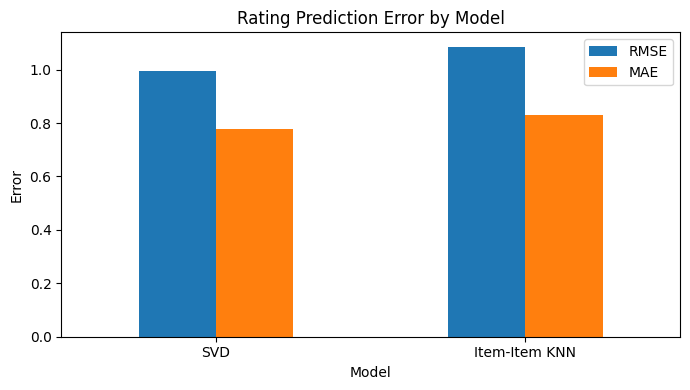

In [247]:
# Plot RMSE and MAE for item-item vs SVD
rating_model_comparison.set_index("Model")[["RMSE_mean", "MAE_mean"]].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Rating Prediction Error by Model")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(["RMSE", "MAE"])
plt.tight_layout()
plt.show()

We can see the slightly better SVD performance compared to Item-Item KNN on the simple bar plot. 

In [248]:
# Compare Recommendation Outputs for the Same Users

user_id_1="OJorsQjotS1dIv--IVifCA"
user_id_2="ewF8tQ01PgwSJbWEdFKS8A"

users_to_compare = [
    user_id_1,
    user_id_2
]

for user_id in users_to_compare:
    print(f"\n============================================================")
    print(f"Recommendations for user: {user_id}")
    print(f"============================================================\n")

    print("Content-Based Recommendations")
    content_recs = get_content_based_recommendations(user_id, top_n=3)
    display(content_recs)

    print("Item-Item KNN Recommendations")
    item_item_recs = get_item_item_recommendations(user_id, top_n=3)
    display(item_item_recs)

    print("SVD Recommendations")
    svd_recs = get_svd_recommendations(user_id, top_n=3)
    display(svd_recs)


Recommendations for user: OJorsQjotS1dIv--IVifCA

Content-Based Recommendations


,name,clean_categories,score
3540,Bumblefish Sushi & More,"Sushi Bars, Specialty Food, Asian Fusion, Seaf...",0.612330
381,Dream House Asian Bistro,"Sushi Bars, Thai, Asian Fusion, Japanese, Chinese",0.578434
853,Umai Royal,"Bars, Asian Fusion, Sushi Bars, Chinese, Japan...",0.556895


Item-Item KNN Recommendations


,name,clean_categories,predicted_rating
20,The Irish Times,"Nightlife, Bars, Beer, Wine & Spirits, Pubs, I...",5.0
29,Minas Pizza,Pizza,5.0
35,Breakfast Boutique Chestnut Hill,Breakfast & Brunch,5.0


SVD Recommendations


...

,name,clean_categories,score
920,Philly Pretzel Factory,"Pretzels, Hot Dogs, Bakeries",1.0
1640,Philly Pretzel Factory,"Bakeries, Pretzels, Hot Dogs",1.0
2053,Philly Pretzel Factory,"Bakeries, Pretzels, Hot Dogs",1.0


Item-Item KNN Recommendations


,name,clean_categories,predicted_rating
0,St Honore Pastries,"Bubble Tea, Coffee & Tea, Bakeries",3.847713
1,Tuna Bar,"Sushi Bars, Japanese",3.847713
2,BAP,Korean,3.847713


SVD Recommendations


,name,clean_categories,predicted_rating,business_id
0,Laurel,"French, American (New)",4.143127,fEqiXG_B-fn__w0aeF3nBQ
1,Barclay Prime,Steakhouses,4.063705,wbDRmtxaKRpBOjutvV6TEA
2,Beiler's Bakery,"Donuts, Food Stands, Specialty Food, Bakeries,...",4.053958,atZ_olNKXOG4rEr6mccN8g


Overall, the differences between the recommendation lists show that each model has its own behavior. Content-based is the easiest to explain, item-item is more sensitive to sparse overlap between businesses, and SVD gives smoother predicted ratings by learning broader patterns from the ratings data.

I would probably go with the SVD recommendations. It does not fall into the same pitfall as the content-based recommender did with `ewF8tQ01PgwSJbWEdFKS8A`, where it recommended multiple pretzel and hot dog businesses because that user had a more unique review history and the Philly Pretzel Factory category match was so strong. Compared to item-item, it is a more difficult comparison, but the RMSE and MAE scores favor SVD. SVD also avoids some of the weirdness from item-item, like predicted ratings maxing out at 5.0 or multiple recommendations getting the exact same score.

### Comments

A ranking-based evaluation such as Precision@K or Recall@K would allow all three recommenders to be compared directly, but implementing that would be out of scope for this project. However, it's doable. 